In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
from pandas import read_csv
df = read_csv('placement_predict_50k Dataset.csv')

In [5]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   StudentID  Gender       City CollegeTier Stream Specialisation Hostel  \
0          1    Male  Ahmedabad       Tier2    ECE     Networking     No   
1          2  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2          3    Male    Kolkata       Tier2     IT    DataScience    Yes   
3          4    Male     Jaipur       Tier1     CS             AI     No   
4          5    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  ...  Publications  \
0                No       6.02       6.54  ...             0   
1               Yes       5.84       5.12  ...             0   
2                No       4.91       5.29  ...             0   
3                No       7.67       8.03  ...             0   
4                No       8.14       8.97  ...             1   

   AptitudeTestScore  SoftSkillsRating  CodingTestScore  MockInterviewScore  \
0               66.7               2.2             49.4          

In [6]:
print("\nDataset shape:")
print(df.shape)



Dataset shape:
(50000, 32)


In [7]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              50000 non-null  object 
 5   Specialisation      50000 non-null  object 
 6   Hostel              50000 non-null  object 
 7   HistoryOfBacklogs   50000 non-null  object 
 8   SGPA_Sem1           50000 non-null  float64
 9   SGPA_Sem2           50000 non-null  float64
 10  SGPA_Sem3           50000 non-null  float64
 11  SGPA_Sem4           50000 non-null  float64
 12  SGPA_Sem5           50000 non-null  float64
 13  SGPA_Sem6           50000 non-null  float64
 14  SGPA_Sem7           50000 non-null  float64
 15  SGPA_Sem8           50000 non-n

In [8]:
print("\nStatistical summary:")
print(df.describe())
print(df.isnull().sum())



Statistical summary:
          StudentID     SGPA_Sem1     SGPA_Sem2     SGPA_Sem3     SGPA_Sem4  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean   25000.500000      7.210583      7.222243      7.235398      7.247290   
std    14433.901067      1.517846      1.532008      1.551632      1.570629   
min        1.000000      4.000000      4.000000      4.000000      4.000000   
25%    12500.750000      6.090000      6.090000      6.080000      6.070000   
50%    25000.500000      7.190000      7.210000      7.220000      7.240000   
75%    37500.250000      8.340000      8.360000      8.400000      8.430000   
max    50000.000000     10.000000     10.000000     10.000000     10.000000   

          SGPA_Sem5     SGPA_Sem6     SGPA_Sem7     SGPA_Sem8          CGPA  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       7.258639      7.274511      7.282720      7.293704      7.246154   
std        1.587829      1.60

In [9]:
X = df[['CGPA']]       # Independent variable
y = df['Salary Package']     # Dependent variable

In [10]:
print("Independent Variable (X): CGPA")
print("Dependent Variable (y): Package")


Independent Variable (X): CGPA
Dependent Variable (y): Package


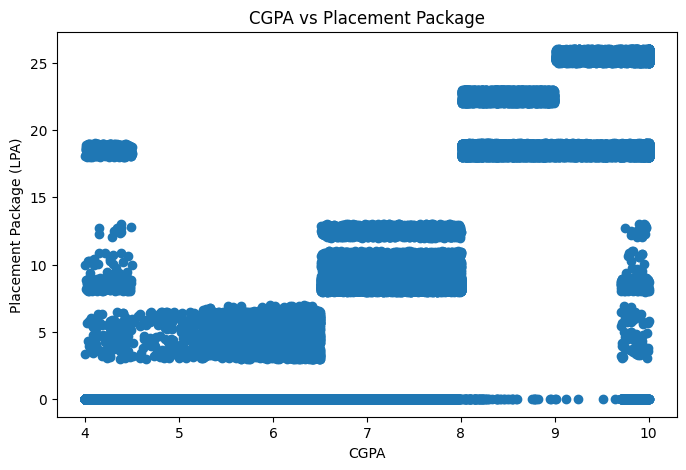

In [11]:
#X = CGPA → input
#y = Package → output/target
# Visualize the relationship
plt.figure(figsize=(8, 5))


plt.scatter(X, y)


plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("CGPA vs Placement Package")


plt.show()



In [12]:
#Students can observe that as CGPA increases, package generally increases.

# Split the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


print("Training data:")
print(X_train)


print("\nTesting data:")
print(X_test)
#Here:

#80% → Training data
#20% → Testing data



Training data:
       CGPA
39087  9.10
30893  8.23
45278  4.44
16398  6.59
13653  7.46
...     ...
11284  5.35
44732  6.99
38158  5.89
860    8.28
15795  9.74

[40000 rows x 1 columns]

Testing data:
       CGPA
33553  8.79
9427   4.78
199    6.81
12447  5.91
39489  5.89
...     ...
28567  6.72
25079  6.65
18707  6.75
15200  8.08
5857   6.86

[10000 rows x 1 columns]


In [13]:
# Create the Linear Regression model
model = LinearRegression()


In [14]:
#9. Train the model
model.fit(X_train, y_train)


print("Model training completed.")
# Find the slope and intercept
print("Slope (β1):", model.coef_[0])
print("Intercept (β0):", model.intercept_)


Model training completed.
Slope (β1): 4.4973512799526505
Intercept (β0): -23.048810684764533


In [15]:
# Predict the test data
y_pred = model.predict(X_test)


print("Actual values:")
print(y_test.values)


print("\nPredicted values:")
print(y_pred)
# Compare actual and predicted values
comparison = pd.DataFrame({
    'CGPA': X_test['CGPA'].values,
    'Actual Package': y_test.values,
    'Predicted Package': y_pred
})



Actual values:
[18.48  0.    0.   ...  0.   22.42  8.78]

Predicted values:
[16.48290707 -1.55147157  7.57815153 ...  7.30831045 13.28978766
  7.8030191 ]


In [16]:
#print(comparison)
#Calculate R²
r2 = r2_score(y_test, y_pred)


print("R² Score:", r2)
print("R² Percentage:", r2 * 100, "%")
# Calculate MAE and MSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)


print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

R² Score: 0.6698734044476139
R² Percentage: 66.98734044476139 %
Mean Absolute Error: 3.7632724352826057
Mean Squared Error: 25.7837186844099


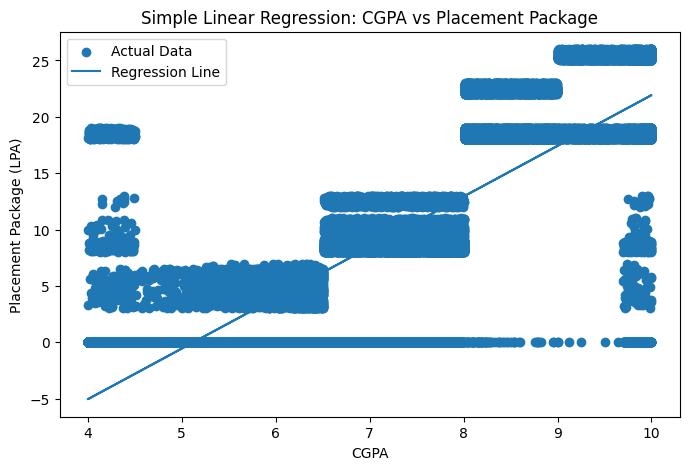

In [17]:
# Draw the regression line
plt.figure(figsize=(8, 5))


plt.scatter(X, y, label="Actual Data")


plt.plot(X, model.predict(X), label="Regression Line")


plt.xlabel("CGPA")
plt.ylabel("Placement Package (LPA)")
plt.title("Simple Linear Regression: CGPA vs Placement Package")


plt.legend()
plt.show()

#This graph shows:

#Dots → Actual student data
#Straight line → Linear Regression prediction


In [18]:
# Predict the package for a new student

#Suppose a student has 8.5 CGPA.

new_cgpa = [[8.5]]


predicted_package = model.predict(new_cgpa)


print("CGPA:", new_cgpa[0][0])
print("Predicted Placement Package:", predicted_package[0], "LPA")


CGPA: 8.5
Predicted Placement Package: 15.178675194832998 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
# Predict for multiple students
new_students = [[7.0], [8.0], [8.5], [9.0], [9.5]]


predicted_packages = model.predict(new_students)


for cgpa, package in zip(new_students, predicted_packages):
    print(f"CGPA: {cgpa[0]} -> Predicted Package: {package:.2f} LPA")

CGPA: 7.0 -> Predicted Package: 8.43 LPA
CGPA: 8.0 -> Predicted Package: 12.93 LPA
CGPA: 8.5 -> Predicted Package: 15.18 LPA
CGPA: 9.0 -> Predicted Package: 17.43 LPA
CGPA: 9.5 -> Predicted Package: 19.68 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
